# Transpile and Compare, Solutions

In [1]:
!pip install qiskit --quiet
!pip install qiskit[visualization] --quiet


Original GHZ circuit:
depth: 3  size: 3


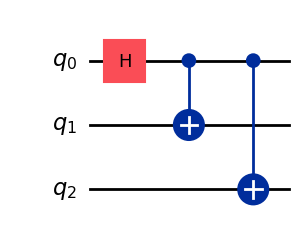

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit.transpiler import CouplingMap

# SOLUTION 1: GHZ circuit from Q9
qc_ghz = QuantumCircuit(3)
qc_ghz.h(0)
qc_ghz.cx(0, 1)
qc_ghz.cx(0, 2)

print("Original GHZ circuit:")
print("depth:", qc_ghz.depth(), " size:", qc_ghz.size())
qc_ghz.draw('mpl')


In [3]:
# SOLUTION 2: transpile for a superconducting-style basis
basis_ibm = ['rz', 'sx', 'x', 'cx']
qc_ibm = transpile(qc_ghz, basis_gates=basis_ibm, optimization_level=1)

print("Transpiled (superconducting basis):")
print("depth:", qc_ibm.depth(), " size:", qc_ibm.size())
print(qc_ibm.count_ops())


Transpiled (superconducting basis):
depth: 5  size: 5
OrderedDict([('rz', 2), ('cx', 2), ('sx', 1)])


In [4]:
# SOLUTION 3: transpile the same original circuit for a trapped-ion-style basis
basis_ion = ['rx', 'ry', 'rz', 'rxx']
qc_ion = transpile(qc_ghz, basis_gates=basis_ion, optimization_level=1)

print("Transpiled (trapped-ion basis):")
print("depth:", qc_ion.depth(), " size:", qc_ion.size())
print(qc_ion.count_ops())


Transpiled (trapped-ion basis):
depth: 6  size: 8
OrderedDict([('rx', 5), ('rxx', 2), ('ry', 1)])


**Typical result:** the superconducting basis needs about 5 gates total (2 rz, 1 sx, 2 cx), while the trapped-ion basis needs more, around 8 gates (5 rx, 2 rxx, 1 ry). This does not mean trapped ions are worse. It just means this particular native gate set needs more elementary operations to express the same circuit. Whether that matters in practice depends on how fast and how reliable each native gate actually is on the real hardware, which varies a lot between platforms.


## Answer 4: connectivity-constrained routing

In [5]:
# SOLUTION 4a: a circuit needing all three pairs of qubits to interact directly
qc_triangle = QuantumCircuit(3)
qc_triangle.h(0)
qc_triangle.cx(0, 1)
qc_triangle.cx(1, 2)
qc_triangle.cx(0, 2)

print("Original triangle circuit:")
print("depth:", qc_triangle.depth(), " size:", qc_triangle.size())


Original triangle circuit:
depth: 4  size: 4


In [6]:
# SOLUTION 4b: transpile with no coupling constraint
qc_tri_free = transpile(qc_triangle, basis_gates=basis_ibm, optimization_level=1)
print("Transpiled, no coupling constraint:")
print("depth:", qc_tri_free.depth(), " size:", qc_tri_free.size())
print(qc_tri_free.count_ops())


Transpiled, no coupling constraint:
depth: 6  size: 6
OrderedDict([('cx', 3), ('rz', 2), ('sx', 1)])


In [7]:
# SOLUTION 4c: transpile with a linear coupling map (0-1-2, no direct 0-2 edge)
coupling = CouplingMap.from_line(3)
qc_tri_line = transpile(qc_triangle, basis_gates=basis_ibm, coupling_map=coupling, optimization_level=1)
print("Transpiled, WITH linear coupling map:")
print("depth:", qc_tri_line.depth(), " size:", qc_tri_line.size())
print(qc_tri_line.count_ops())


Transpiled, WITH linear coupling map:
depth: 9  size: 9
OrderedDict([('cx', 6), ('rz', 2), ('sx', 1)])


**Typical result:** unconstrained, this needs 3 cx gates (6 total ops). With the linear coupling map, it needs 4 cx gates (7 total ops), one extra two-qubit gate. That extra gate is the routing cost: since qubits 0 and 2 are not directly connected on the line, the transpiler has to route their interaction through qubit 1, which needs at least one additional two-qubit operation.

This is a concrete, physical cost. It is not a simulator quirk. Every extra gate is an extra opportunity for the operation to fail on noisy real hardware, so connectivity is a genuine design constraint, not just a bookkeeping detail.


## Bonus: the original GHZ circuit under the same linear coupling map

In [8]:
qc_ghz_line = transpile(qc_ghz, basis_gates=basis_ibm, coupling_map=coupling, optimization_level=1)
print("GHZ circuit, WITH linear coupling map:")
print("depth:", qc_ghz_line.depth(), " size:", qc_ghz_line.size())
print(qc_ghz_line.count_ops())

print()
print("Compare to unconstrained (from earlier):")
print("depth:", qc_ibm.depth(), " size:", qc_ibm.size())


GHZ circuit, WITH linear coupling map:
depth: 5  size: 5
OrderedDict([('rz', 2), ('cx', 2), ('sx', 1)])

Compare to unconstrained (from earlier):
depth: 5  size: 5


**Expected result:** the GHZ circuit needs exactly the same depth and size under the linear coupling map as it did unconstrained: no extra routing gates at all.

**Why:** the GHZ circuit's entangling structure is a star, one qubit (qubit 0) is the control for both CX gates, and the two target qubits never need to interact directly with each other. The transpiler is free to choose which *physical* qubit each *logical* qubit maps to, and it can place the star's center (qubit 0) onto the middle physical qubit of the line. From there, both targets are already adjacent to it, so no routing is ever needed.

The triangle circuit has no such escape: all three qubits need to interact with each other directly, and a 3-qubit line simply does not have enough edges to support that, no matter how you assign logical qubits to physical ones. This is the real, structural difference between a circuit that "fits" a given hardware topology and one that does not.
